### Import libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [2]:
# read dataset
df = pd.read_excel('InterviewTestDataSet.xlsx')

In [3]:
# brwose
df.head()

,Material No.,Category Name,Ordering Month,Ordering Year,Delivery Date,Delivery Date New,Unit price,Total spend
0,100236,DD,9,2015,42264,2015-09-17,1458,79413
1,101590,DD,9,2019,43763,2019-10-25,650,47575
2,103982,BB,10,2016,42688,2016-11-14,472,78524
3,104245,DD,3,2016,42440,2016-03-11,1437,94193
4,104729,DD,10,2021,44502,2021-11-02,1073,35502


In [4]:
print(f'Dataset has {df.shape[0]} rows and {df.shape[1]} columns')

Dataset has 1556 rows and 8 columns


In [5]:
print('Summary statistics for each feature:')
df.describe()

Summary statistics for each feature:


,Material No.,Ordering Month,Ordering Year,Delivery Date,Delivery Date New,Unit price,Total spend
count,1556.000000,1556.000000,1556.000000,1556.000000,1556,1556.000000,1556.000000
mean,553922.812339,6.634319,2019.493573,43848.408740,2020-01-18 09:48:35.167095040,770.739717,50371.976221
min,100236.000000,1.000000,2015.000000,42016.000000,2015-01-12 00:00:00,10.000000,56.000000
25%,334847.500000,4.000000,2017.000000,42970.750000,2017-08-23 18:00:00,410.750000,25731.500000
50%,549972.500000,7.000000,2019.000000,43820.000000,2019-12-21 00:00:00,782.500000,51344.500000
75%,769936.250000,10.000000,2022.000000,44728.000000,2022-06-16 00:00:00,1138.250000,75213.750000
max,999724.000000,12.000000,2024.000000,45685.000000,2025-01-28 00:00:00,1500.000000,99988.000000
std,255109.531678,3.477158,2.848922,1042.662829,NaN,429.624985,28636.183999


In [6]:
# Check for missing values
df.isnull().sum()
print('No Missing Values Found')

No Missing Values Found


In [7]:
# Check for duplicates
df.duplicated().sum()
print('No Duplicates Found')

No Duplicates Found


In [8]:
# add new column for quantity
df['quantity'] = round(df['Total spend']/df['Unit price'])

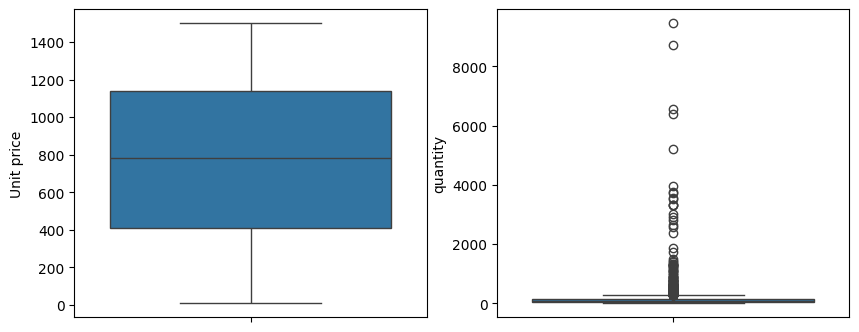

In [9]:
# check for outlier
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y = 'Unit price', data = df, ax = ax[0])
sns.boxplot(y = 'quantity', data = df, ax = ax[1])
plt.show()

In [10]:
# filter out possible outliers
possible_outliers = df[df['quantity'] > df['quantity'].quantile(0.99)]
possible_outliers

,Material No.,Category Name,Ordering Month,Ordering Year,Delivery Date,Delivery Date New,Unit price,Total spend,quantity
293,283684,AA,12,2024,45685,2025-01-28,33,96594,2927.0
350,316867,BB,12,2017,43095,2017-12-26,32,96812,3025.0
375,330238,DD,8,2020,44054,2020-08-11,18,93664,5204.0
423,348576,FF,7,2017,42954,2017-08-07,21,82914,3948.0
800,564101,BB,10,2023,45206,2023-10-07,10,87227,8723.0
1046,702029,FF,11,2024,45607,2024-11-11,24,85264,3553.0
1076,718121,BB,5,2016,42496,2016-05-06,16,53272,3330.0
1117,742994,FF,10,2024,45569,2024-10-04,23,86309,3753.0
1121,744801,FF,4,2017,42880,2017-05-25,14,39565,2826.0
1164,768434,AA,3,2022,44655,2022-04-04,10,94615,9462.0


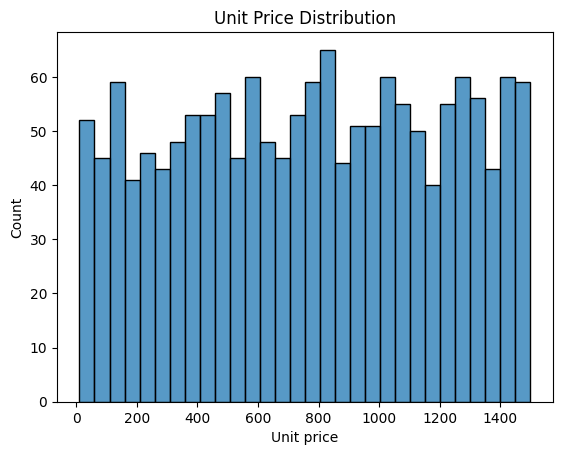

In [11]:
# check unit price distribution
sns.histplot(df['Unit price'], bins=30)
plt.title('Unit Price Distribution')
plt.show()

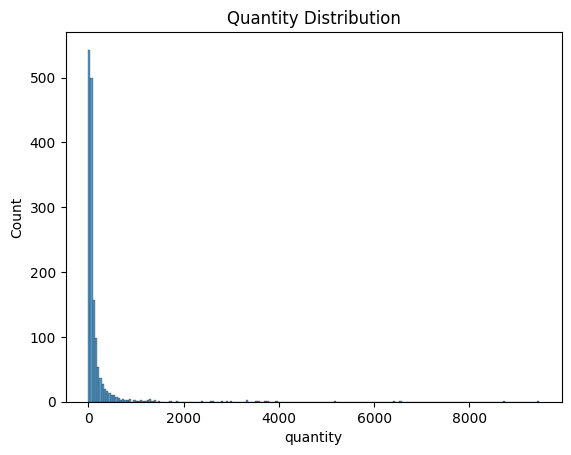

In [12]:
# check quantity distribution
sns.histplot(df['quantity'], bins=200)
plt.title('Quantity Distribution')
plt.show()

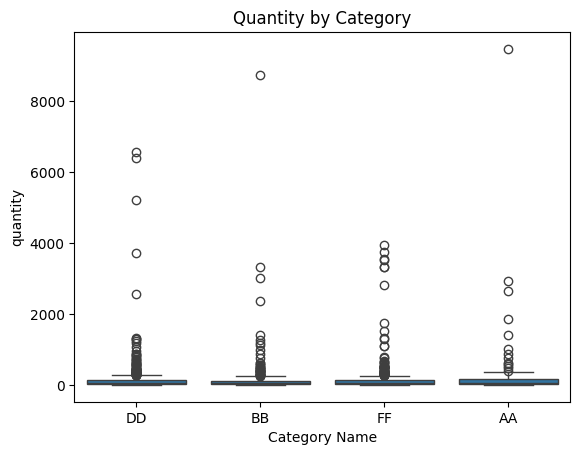

In [13]:
# boxplots of quantity by categories
sns.boxplot(x='Category Name', y='quantity', data=df)
plt.title('Quantity by Category')
plt.show()

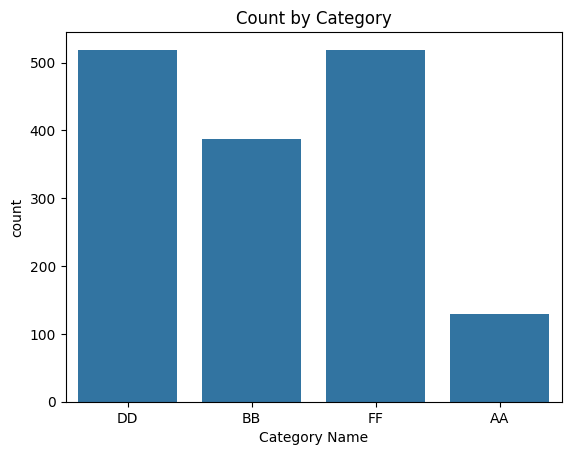

In [14]:
# check frequency of categories
sns.countplot(x='Category Name', data = df)
plt.title('Count by Category')
plt.show()

In [15]:
# remove redundant features
df = df[['Category Name', 'Ordering Year', 'Unit price', 'quantity']]
df = df[df['Ordering Year'].isin([2024, 2023, 2022, 2021, 2020])] # get 5 years data
df.head()

,Category Name,Ordering Year,Unit price,quantity
4,DD,2021,1073,33.0
6,FF,2021,515,2.0
10,BB,2021,1384,5.0
11,AA,2021,1042,89.0
13,BB,2021,1299,66.0


In [16]:
# create dummy variable for category
df = pd.get_dummies(df, columns = ['Category Name'], drop_first = True)
df.head()

,Ordering Year,Unit price,quantity,Category Name_BB,Category Name_DD,Category Name_FF
4,2021,1073,33.0,False,True,False
6,2021,515,2.0,False,False,True
10,2021,1384,5.0,True,False,False
11,2021,1042,89.0,False,False,False
13,2021,1299,66.0,True,False,False


In [17]:
# change column names
df.columns = ['year', 'unit_price', 'quantity', 'category_bb', 'category_dd', 'category_ff']
df.head()

,year,unit_price,quantity,category_bb,category_dd,category_ff
4,2021,1073,33.0,False,True,False
6,2021,515,2.0,False,False,True
10,2021,1384,5.0,True,False,False
11,2021,1042,89.0,False,False,False
13,2021,1299,66.0,True,False,False


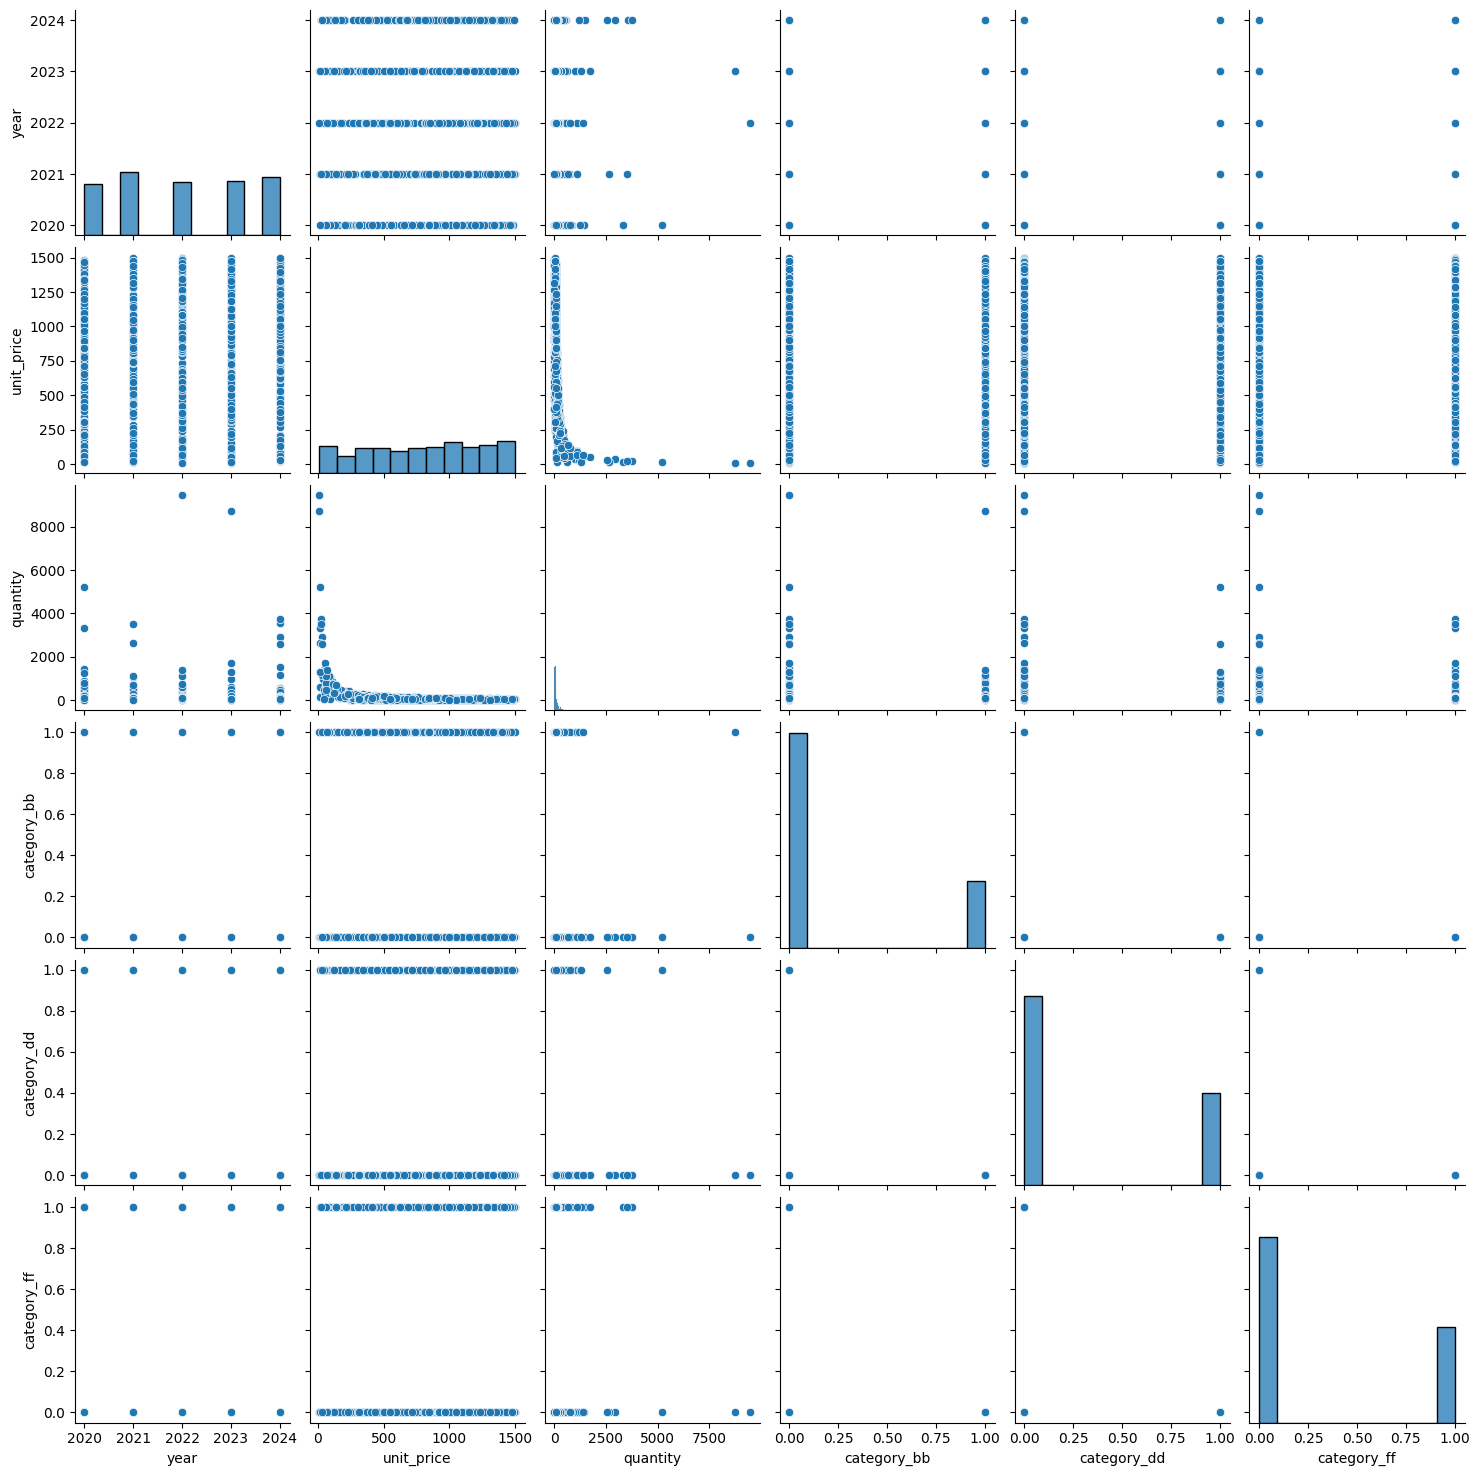

In [19]:
# Check multicolinearity
sns.pairplot(df)
plt.show()

By inspecting the pairplots, there's no significant multi-colinearity existing among features.

In [20]:
# Split response variables and predictors
X = df.drop('quantity', axis = 1)
y = df['quantity']

In [21]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 512)

In [22]:
# Standard Scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# build initial model/baseline model
rf = RandomForestRegressor(n_estimators = 200, random_state = 512)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)**(1/2)
print('RMSE: ', rmse)

RMSE:  442.42289295155166


In [24]:
r2 = rf.score(X_test, y_test)
print('R^2: ', r2)

R^2:  0.7160946894716473


In [25]:
param_grid = {'max_depth': [1, 2, 3, 4],
             'n_estimators': [100, 200, 300, 400]}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [1, 2, 3, 4],
                         'n_estimators': [100, 200, 300, 400]},
             scoring='neg_mean_squared_error')

In [26]:
grid.best_params_

{'max_depth': 3, 'n_estimators': 300}

In [27]:
best_score = np.sqrt(-grid.best_score_)
best_score

np.float64(389.77762287627826)

### Validate Final Model on Test Set

In [28]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)**(1/2)
print('RMSE: ', rmse)


RMSE:  422.4044090087945


In [29]:
r2 = best_model.score(X_test, y_test)
print('R^2: ', r2)


R^2:  0.7412053946617647


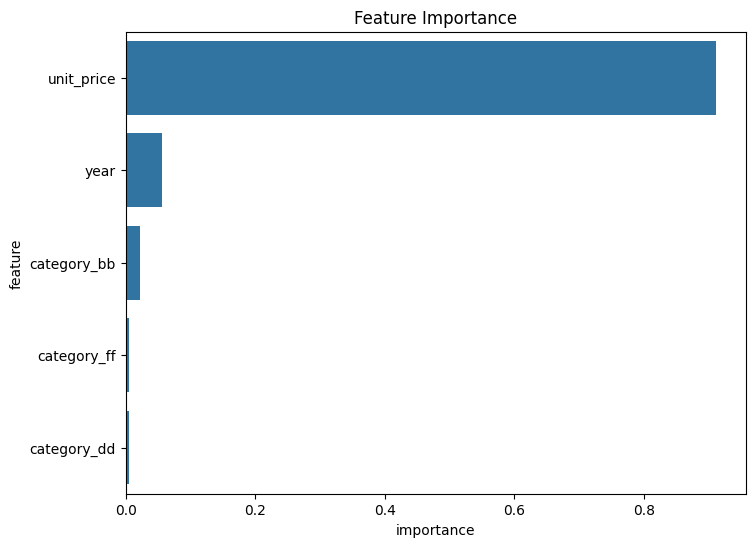

In [30]:
# check feature importances
importances = best_model.feature_importances_
importance_df = pd.DataFrame({'feature': X.columns, 'importance': importances})
importance_df.sort_values('importance', ascending = False, inplace = True)

plt.figure(figsize=(8,6))

sns.barplot(
    x="importance",
    y="feature",
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

### Compare with Other Model

In [33]:
# compare with other models
lr = LinearRegression()
lr.fit(X_train, y_train)
r2 = lr.score(X_test, y_test)
print('R^2 of Linear Regression: ', r2)

R^2 of Linear Regression:  0.09771816314937043


### Conclusion

The final model is done through feature engineering like standard scaling, one-hot encoding, with tuned hyperparameters using GridSearch of a Random Forest model. Through this initial tryout, we've got a pretty significant result with R^2 of 0.74. We also compared with linaer regression result of a R^2 0.1 which proves that the predictive model outperformed. 
 
Comparing with the other version (predicting category using quantity): the model predictive accuracy is around 0.35. The problem itself is a multi-class classification with 4 classes. By default, the model as expected guessing rate of 0.25, which means, the predictive model (predicting category) has learned pattens within the dataset. But no significant causal relationship founded.

For next steps, 
1. it is recommended to try other advanced ensemble models like XGBoost and better hyperparameter tuning frame work to further improve the perforamnce of the predictive model
2. try to include more features like seasonality in the model to see wheather the model performance could improve
3. the current dataset has 1556 rows, which is relatively small -- if possible, train the model on larger dataset would also help the improvment of predictive capabilities